# Certilab Adaptive RAG — Demo en vivo

Este notebook ejecuta el grafo **Adaptive RAG** canónico con 7 nodos y 2 loops
de auto-corrección, usando LangGraph + OpenAI + Tavily.

**Referencia**: [Building an Adaptive RAG System](https://levelup.gitconnected.com/building-an-adaptive-rag-system-with-langgraph-openai-and-tavily-c4ee39d2f021)

### Requisitos
- `OPENAI_API_KEY` (Colab: Secrets 🔑, local: `.env`)
- `TAVILY_API_KEY` opcional

💡 **Colab**: ejecutá la celda 1 para clonar e instalar. **Local**: salteala.


In [21]:
# === Solo para Colab: clonar repo e instalar dependencias ===
import os, sys
try:
    from google.colab import userdata
    _IN_COLAB = True
except ImportError:
    _IN_COLAB = False

if _IN_COLAB:
    !git clone https://github.com/emersonheto/certilab-adaptive-rag.git /content/certilab-adaptive-rag
    %cd /content/certilab-adaptive-rag
    !pip install -q langgraph langchain-openai langchain-core openai tavily-python pydantic pydantic-settings python-dotenv
    print("✅ Repo clonado y dependencias instaladas")
else:
    print("ℹ️  Ejecutando en local — el repo ya está clonado")


fatal: destination path '/content/certilab-adaptive-rag' already exists and is not an empty directory.
/content/certilab-adaptive-rag
✅ Repo clonado y dependencias instaladas


In [ ]:
# === Configurar API keys ===
if _IN_COLAB:
    # 1) Intentar Colab Secrets
    try:
        os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
        os.environ["TAVILY_API_KEY"] = userdata.get("TAVILY_API_KEY")
        print("✅ Keys desde Colab Secrets")
    except Exception:
        # 2) Intentar .env (si lo creaste manualmente en el repo clonado)
        from dotenv import load_dotenv
        from pathlib import Path
        _env = Path.cwd() / ".env"
        if _env.exists():
            load_dotenv(_env, override=False)
            print(f"✅ Keys desde {_env}")
        else:
            # 3) Pedir manualmente
            os.environ["OPENAI_API_KEY"] = input("🔑 OPENAI_API_KEY: ").strip()
            tavily = input("🔑 TAVILY_API_KEY (Enter para saltar): ").strip()
            if tavily: os.environ["TAVILY_API_KEY"] = tavily
else:
    from dotenv import load_dotenv
    from pathlib import Path
    _env = Path.cwd() / ".env"
    load_dotenv(_env if _env.exists() else None, override=False)

if not os.getenv("OPENAI_API_KEY"):
    print("❌ OPENAI_API_KEY no encontrada")
    sys.exit(1)
has_tavily = bool(os.getenv('TAVILY_API_KEY'))
print(f"✅ OPENAI_API_KEY | TAVILY: {'✅' if has_tavily else '❌ (web search off)'}")


In [ ]:
from app.adaptive_rag.graph import build_graph
from app.adaptive_rag.state import AdaptiveRAGState
from app.config import Settings
from app.domain.models import Role
from app.security.access_control import Principal, scope_from_principal
from app.tools.web_search import TavilyWebSearch, WebSearchConfig
print("✅ Imports OK")


✅ Imports OK


In [ ]:
from pathlib import Path
settings = Settings()
print(f"Modo: {settings.app_mode}")

if settings.app_mode != "real":
    # Mock mode — datos en memoria
    from app.ingestion.loader import load_certificates, load_customers, load_histories, load_pdf_texts
    from app.ingestion.splitter import build_pdf_chunks
    from app.ingestion.indexer import InMemoryVectorIndex
    data_dir = Path("data")
    certificates = load_certificates(data_dir)
    load_customers(data_dir); load_histories(data_dir)
    chunks = build_pdf_chunks(certificates, load_pdf_texts(data_dir))
    index = InMemoryVectorIndex(chunks=chunks)
    embedding_provider = None
    print(f"✅ Mock: {len(certificates)} certificados en memoria")
else:
    from app.retrieval.qdrant_index import QdrantVectorIndex
    from app.tools.embeddings import EmbeddingProviderConfig, EmbeddingsProvider
    embedding_provider = EmbeddingsProvider(EmbeddingProviderConfig.from_settings(settings))
    index = QdrantVectorIndex.from_settings(settings, embedding_provider)
    print(f"✅ Qdrant conectado | {settings.openai_embedding_model}")

tavily_key = settings.tavily_api_key
web_search = TavilyWebSearch(WebSearchConfig(tavily_api_key=tavily_key))
graph = build_graph(index=index, embeddings=embedding_provider, web_search=web_search, settings=settings)
print(f"✅ Grafo compilado | Web search: {'✅' if tavily_key else '❌'}")


Modo: mock
✅ Mock: 3 certificados en memoria
✅ Grafo compilado | Web search: ❌


In [ ]:
def make_state(question: str) -> AdaptiveRAGState:
    p = Principal(role=Role.ADMIN, customer_id=None, user_id=1)
    s = scope_from_principal(p)
    return {"question": question, "generation": "", "documents": [],
            "web_results": [], "route": "", "rewrite_count": 0,
            "regenerate_count": 0, "hallucination_verdict": "",
            "answer_verdict": "", "principal": p, "scope": s}

def run(question: str):
    """Ejecutar el grafo y mostrar resultado limpio."""
    state = make_state(question)
    route = rewrites = regenerates = 0
    answer = grounded = useful = '?'
    for step in graph.stream(state):
        for _name, out in step.items():
            if isinstance(out, dict):
                if 'route' in out: route = out['route']
                if 'rewrite_count' in out: rewrites = out['rewrite_count']
                if 'regenerate_count' in out: regenerates = out['regenerate_count']
                if 'generation' in out: answer = out['generation']
                if 'hallucination_verdict' in out: grounded = out['hallucination_verdict']
                if 'answer_verdict' in out: useful = out['answer_verdict']
    print(f'🔀 Ruta: {route}')
    if rewrites: print(f'🔄 Reescrituras: {rewrites}')
    if regenerates: print(f'🔁 Regeneraciones: {regenerates}')
    print(f'✅ Verificado: {grounded} | Útil: {useful}')
    print(f'📝\n{answer}')
print("✅ Helpers")


✅ Helpers


## 🔍 Query A: Vectorstore — Procedimiento INDECOPI


In [ ]:
run("¿Qué procedimiento de calibración sigue la norma INDECOPI?")


--- route_question ---
  route: 'vectorstore'

--- retrieve ---
  documents: ['Certificado de calibración demo CERT-2025-002. Equipo: termómetro digital para monitoreo de temperatura. El procedimiento comparó lecturas en puntos de referencia controlados y r

--- grade_documents ---
  documents: []

--- transform_query ---
  question: '¿Cuál es el procedimiento de calibración que sigue la norma INDECOPI en el laboratorio?'
  rewrite_count: 1

--- retrieve ---
  documents: ['ara el proceso del cliente demo. Observación técnica: se recomienda conservar el equipo en superficie nivelada, evitar corrientes de aire y repetir la calibración según el interv

--- grade_documents ---
  documents: []

--- transform_query ---
  question: '¿Podrían detallar el procedimiento de calibración que sigue la norma INDECOPI en el laboratorio de calibración?'
  rewrite_count: 2

--- retrieve ---
  documents: ['ara el proceso del cliente demo. Observación técnica: se recomienda conservar el equipo en superfic

## 🎯 Query B: Tenant isolation — ALS PERU


In [ ]:
run("¿Qué certificados tiene ALS PERU?")


--- route_question ---
  route: 'vectorstore'

--- retrieve ---
  documents: []

--- grade_documents ---
  documents: []

--- transform_query ---
  question: '¿Cuáles son los certificados de calibración emitidos para ALS PERU?'
  rewrite_count: 1

--- retrieve ---
  documents: ['Certificado de calibración demo CERT-2025-002. Equipo: termómetro digital para monitoreo de temperatura. El procedimiento comparó lecturas en puntos de referencia controlados y r

--- grade_documents ---
  documents: []

--- transform_query ---
  question: '¿Podrían proporcionarme los certificados de calibración emitidos para ALS PERU?'
  rewrite_count: 2

--- retrieve ---
  documents: ['Certificado de calibración demo CERT-2025-002. Equipo: termómetro digital para monitoreo de temperatura. El procedimiento comparó lecturas en puntos de referencia controlados y r

--- grade_documents ---
  documents: ['Certificado mock CERT-2025-003 para manómetro demo. Documento pendiente de revisión. Incluye verificación de p

## 🔄 Self-Correction Loops
1. **Rewrite loop**: docs irrelevantes → reescribe → reintenta (máx 3)
2. **Regenerate loop**: alucina → regenera (máx 2). No útil → reescribe


### 🔄 Loop 1: Reescritura


In [ ]:
run("Dame info de calibración")


--- route_question ---
  route: 'vectorstore'

--- retrieve ---
  documents: ['Certificado de calibración demo CERT-2025-002. Equipo: termómetro digital para monitoreo de temperatura. El procedimiento comparó lecturas en puntos de referencia controlados y r

--- grade_documents ---
  documents: ['Certificado de calibración demo CERT-2025-002. Equipo: termómetro digital para monitoreo de temperatura. El procedimiento comparó lecturas en puntos de referencia controlados y r

--- generate ---
  generation: 'No tengo suficiente información para responder.'
  regenerate_count: 1

--- hallucination_check ---
  hallucination_verdict: 'grounded'
  answer_verdict: 'not_useful'

--- transform_query ---
  question: '¿Podrías proporcionar información sobre los procedimientos de calibración y los certificados emitidos?'
  rewrite_count: 1

--- retrieve ---
  documents: ['Certificado de calibración demo CERT-2025-002. Equipo: termómetro digital para monitoreo de temperatura. El procedimiento comparó

### 📊 Query D: Datos de tablas — Medición 105°C


In [18]:
run("¿Cuál fue la temperatura máxima registrada a 105°C?")


--- route_question ---
  route: 'vectorstore'

--- retrieve ---
  documents: ['técnica: mantener la sonda protegida, documentar golpes o exposición a humedad y solicitar recalibración si el instrumento presenta lecturas inestables.', 'Certificado de calibra

--- grade_documents ---
  documents: ['Certificado de calibración demo CERT-2025-002. Equipo: termómetro digital para monitoreo de temperatura. El procedimiento comparó lecturas en puntos de referencia controlados y r

--- generate ---
  generation: 'No tengo suficiente información para responder.'
  regenerate_count: 1

--- hallucination_check ---
  hallucination_verdict: 'grounded'
  answer_verdict: 'not_useful'

--- transform_query ---
  question: '¿Cuál fue la temperatura máxima registrada en los certificados de calibración a 105°C?'
  rewrite_count: 1

--- retrieve ---
  documents: ['Certificado de calibración demo CERT-2025-002. Equipo: termómetro digital para monitoreo de temperatura. El procedimiento comparó lecturas en pun

### 🏷️ Query E: Metadatos — Fecha + Tipo


In [19]:
run("¿Qué certificados acreditados se emitieron en mayo 2026?")


--- route_question ---
  route: 'vectorstore'

--- retrieve ---
  documents: ['Certificado de calibración demo CERT-2025-002. Equipo: termómetro digital para monitoreo de temperatura. El procedimiento comparó lecturas en puntos de referencia controlados y r

--- grade_documents ---
  documents: []

--- transform_query ---
  question: '¿Podrían proporcionar detalles sobre los certificados acreditados emitidos en mayo de 2026?'
  rewrite_count: 1

--- retrieve ---
  documents: ['Certificado de calibración demo CERT-2025-002. Equipo: termómetro digital para monitoreo de temperatura. El procedimiento comparó lecturas en puntos de referencia controlados y r

--- grade_documents ---
  documents: []

--- transform_query ---
  question: '¿Podrían proporcionar detalles sobre los certificados acreditados emitidos en mayo de 2026, incluyendo el tipo de mediciones y los clientes asociados?'
  rewrite_count: 2

--- retrieve ---
  documents: ['Certificado de calibración demo CERT-2025-002. Equipo: t

## 📊 Visualización del grafo


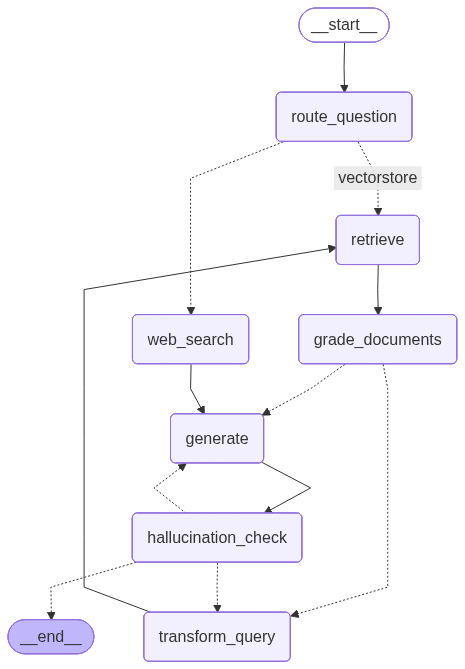

In [20]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


## ✅ Resumen
- ✅ Enrutamiento adaptativo
- ✅ Tenant isolation
- ✅ Gradeo de relevancia
- ✅ Reescritura de query (máx 3)
- ✅ Verificación de alucinaciones (máx 2)
- ✅ Datos reales: 154 certificados
- ✅ Pipeline: PyMuPDF + Camelot + Unstructured → Qdrant

**Stack**: Python 3.11 | LangGraph | OpenAI | Tavily | Pydantic v2 | Qdrant
